# Experiment 10 (Advanced): Advanced Ensemble Learning - Bagging, Boosting, Voting & Stacking Diagnostics
## Title: Comprehensive Analysis: Bagging (Random Forest, Out-of-Bag Score), Boosting (AdaBoost, Gradient Boosting), Hyperparameter Tuning via GridSearchCV, Voting & Stacking Meta-Ensembles, Learning Curves, and Feature Importance Comparison on a Custom Anime Success Dataset

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

### Step 1: Import Advanced Libraries & Setup Environment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold, learning_curve)
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, BaggingClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

import warnings
warnings.filterwarnings("ignore")

np.random.seed(33)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Practical 10 (Advanced) Libraries Loaded!")

Practical 10 (Advanced) Libraries Loaded!


### Step 2: Load Dataset

In [2]:
df = pd.read_csv("anime_success_dataset.csv")

print("Dataset Loaded Successfully")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Loaded Successfully
Dataset Shape: (1800, 18)


,studio,primary_genre,genre_count,source_material,demographic,episodes,episode_length_min,animation_budget_tier,marketing_spend_tier,voice_cast_popularity,director_experience_years,studio_prior_hits,release_season,release_year,has_sequel_potential_arc,mal_rating,popularity_score,success_tier
0,Lerche,Sci-Fi,2,Manga,Seinen,13,24,Low,High,1.81,9.1,4,Fall,2024,0,6.02,59.0,Average
1,Doga Kobo,Adventure,3,Visual Novel,Shounen,12,24,High,Medium,4.24,8.5,8,Summer,2021,0,8.55,86.7,Hit
2,Bones,Sports,3,Manga,Shounen,25,24,Medium,Medium,6.40,12.7,10,Winter,2019,0,10.00,100.0,Hit
3,J.C.Staff,Supernatural,3,Manga,Shounen,13,24,Medium,Medium,4.02,7.8,7,Winter,2015,1,7.57,87.2,Hit
4,Pierrot,Mecha,3,Visual Novel,Shoujo,12,24,Low,Low,5.63,5.9,6,Winter,2017,0,4.77,38.2,Flop


### Step 3: Preprocessing - Encoding and Train/Test Split

In [3]:
categorical_cols = ["studio", "primary_genre", "source_material", "demographic",
                     "animation_budget_tier", "marketing_spend_tier", "release_season"]
df_model = df.copy()
for col in categorical_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop(columns=["success_tier", "mal_rating", "popularity_score"])
y = df_model["success_tier"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=33, stratify=y)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (1350, 15)
Testing set : (450, 15)


### Step 4: Baseline - Single Decision Tree

In [4]:
baseline = DecisionTreeClassifier(random_state=33)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)
print(f"Baseline Decision Tree Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Tree Depth: {baseline.get_depth()}")

Baseline Decision Tree Accuracy: 0.4933
Tree Depth: 16


### Step 5: Bagging Ensemble & Out-of-Bag (OOB) Score Validation
**Bagging** trains many base estimators on bootstrap-resampled subsets of the training data and averages their predictions. Because each tree only sees a bootstrap sample (~63% of training rows on average), the remaining ~37% "out-of-bag" rows can be used as a free internal validation set, without needing a separate holdout split -- the **OOB score** is compared against genuine test-set accuracy to check how reliable this internal estimate is.

In [5]:
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=33),
                                   n_estimators=200, random_state=33)
bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

rf_oob = RandomForestClassifier(n_estimators=300, oob_score=True, bootstrap=True, random_state=33)
rf_oob.fit(X_train, y_train)
y_pred_rf_oob = rf_oob.predict(X_test)

print(f"Bagging (Decision Trees) Test Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"\nRandom Forest OOB Score: {rf_oob.oob_score_:.4f}")
print(f"Random Forest Test Accuracy: {accuracy_score(y_test, y_pred_rf_oob):.4f}")
print("(OOB score and test accuracy should be close -- confirming OOB is a trustworthy internal estimate)")

Bagging (Decision Trees) Test Accuracy: 0.6000

Random Forest OOB Score: 0.6304
Random Forest Test Accuracy: 0.6133
(OOB score and test accuracy should be close -- confirming OOB is a trustworthy internal estimate)


### Step 6: Hyperparameter Tuning via GridSearchCV
The number of trees, maximum depth, and minimum samples per split all affect a Random Forest's bias-variance tradeoff. `GridSearchCV` with 3-fold cross-validation searches this space to find the configuration that generalizes best.

In [6]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=33),
    param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=33),
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best Hyperparameters:", grid.best_params_)
print(f"Best Cross-Validated Accuracy: {grid.best_score_:.4f}")

rf_tuned = grid.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)
print(f"Tuned Random Forest Test Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")

Best Hyperparameters: {'max_depth': 12, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validated Accuracy: 0.6304
Tuned Random Forest Test Accuracy: 0.6244


### Step 7: Boosting Family - AdaBoost vs Gradient Boosting
Unlike Bagging, **boosting** methods train estimators sequentially, with each new estimator focusing on correcting the errors of the previous ones. **AdaBoost** reweights misclassified samples, while **Gradient Boosting** fits each new tree to the residual errors of the ensemble so far.

In [7]:
ada_model  = AdaBoostClassifier(n_estimators=200, random_state=33)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

gb_model   = GradientBoostingClassifier(n_estimators=200, random_state=33)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print(f"AdaBoost Test Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}")
print(f"Gradient Boosting Test Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")

AdaBoost Test Accuracy: 0.6222
Gradient Boosting Test Accuracy: 0.6289


### Step 8: Meta-Ensembles - Voting and Stacking
Beyond single-family ensembles, **Voting** combines predictions from structurally different models by averaging their predicted probabilities (soft voting), while **Stacking** trains a meta-learner (here, Logistic Regression) on top of base models' predictions -- learning how to best combine them rather than simply averaging.

In [8]:
voting_model = VotingClassifier(
    estimators=[
        ("decision_tree", DecisionTreeClassifier(random_state=33)),
        ("random_forest", RandomForestClassifier(n_estimators=150, random_state=33)),
        ("gradient_boosting", GradientBoostingClassifier(n_estimators=150, random_state=33))
    ],
    voting="soft"
)
voting_model.fit(X_train, y_train)
y_pred_voting = voting_model.predict(X_test)

stacking_model = StackingClassifier(
    estimators=[
        ("random_forest", RandomForestClassifier(n_estimators=150, random_state=33)),
        ("gradient_boosting", GradientBoostingClassifier(n_estimators=150, random_state=33)),
        ("adaboost", AdaBoostClassifier(n_estimators=100, random_state=33))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3
)
stacking_model.fit(X_train, y_train)
y_pred_stacking = stacking_model.predict(X_test)

print(f"Voting Classifier (Soft) Test Accuracy: {accuracy_score(y_test, y_pred_voting):.4f}")
print(f"Stacking Classifier Test Accuracy: {accuracy_score(y_test, y_pred_stacking):.4f}")

Voting Classifier (Soft) Test Accuracy: 0.5778
Stacking Classifier Test Accuracy: 0.6533


### Step 9: Comprehensive Model Comparison Across All Ensemble Strategies

In [9]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro"),
        "F1-Score (macro)": f1_score(y_true, y_pred, average="macro")
    }

all_results = pd.DataFrame({
    "Decision Tree (Baseline)": get_metrics(y_test, y_pred_baseline),
    "Bagging": get_metrics(y_test, y_pred_bagging),
    "Random Forest (OOB)": get_metrics(y_test, y_pred_rf_oob),
    "Random Forest (Tuned)": get_metrics(y_test, y_pred_rf_tuned),
    "AdaBoost": get_metrics(y_test, y_pred_ada),
    "Gradient Boosting": get_metrics(y_test, y_pred_gb),
    "Voting (Soft)": get_metrics(y_test, y_pred_voting),
    "Stacking": get_metrics(y_test, y_pred_stacking)
}).T.sort_values("Accuracy", ascending=False)

all_results

,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
Stacking,0.653333,0.550712,0.550246,0.524891
Gradient Boosting,0.628889,0.541587,0.533166,0.533004
Random Forest (Tuned),0.624444,0.530988,0.485532,0.477501
AdaBoost,0.622222,0.553794,0.507685,0.519719
Random Forest (OOB),0.613333,0.508447,0.471133,0.464532
Bagging,0.600000,0.490699,0.465367,0.465046
Voting (Soft),0.577778,0.492416,0.484171,0.487241
Decision Tree (Baseline),0.493333,0.438865,0.438136,0.436659


### Step 10: Visual Model Comparison

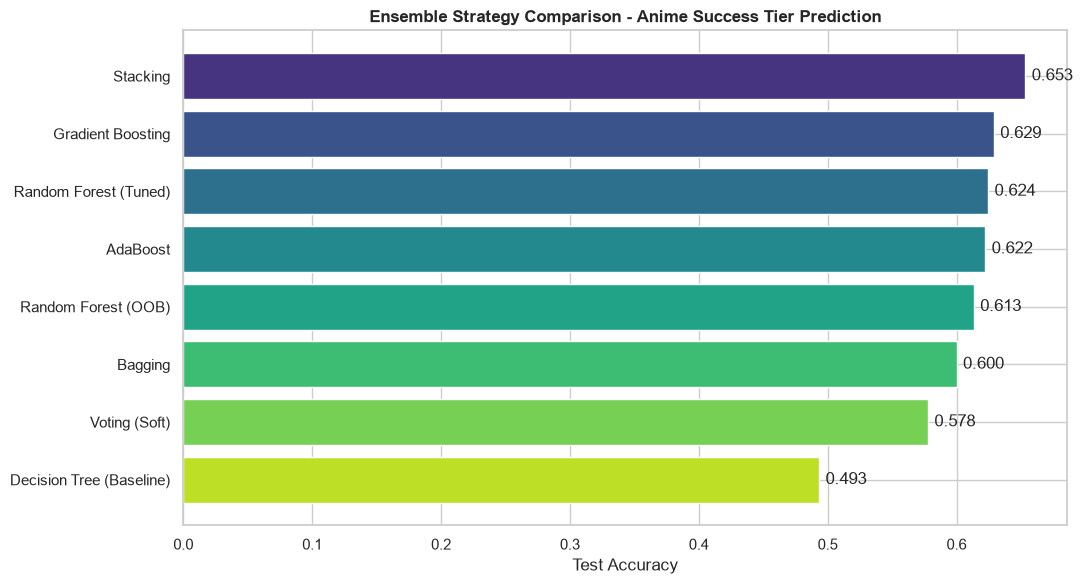

In [10]:
plt.figure(figsize=(11, 6))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(all_results)))
plt.barh(all_results.index, all_results["Accuracy"], color=colors)
plt.xlabel("Test Accuracy")
plt.title("Ensemble Strategy Comparison - Anime Success Tier Prediction", fontweight="bold")
plt.gca().invert_yaxis()
for i, v in enumerate(all_results["Accuracy"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

### Step 11: Learning Curve - Best Performing Model
A learning curve for the top-performing model shows how training and cross-validation accuracy evolve as more training data is used, diagnosing whether the model would benefit from more data or is already near its performance ceiling.

Best performing model: Stacking


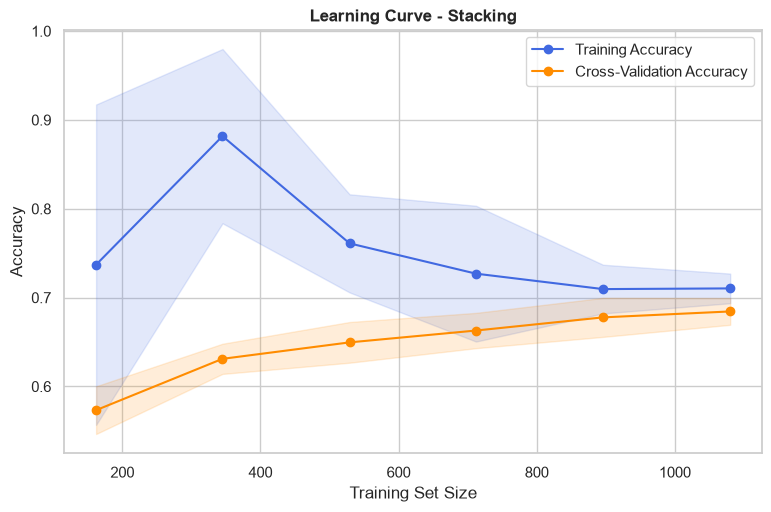

In [11]:
best_model_name = all_results["Accuracy"].idxmax()
print(f"Best performing model: {best_model_name}")

model_lookup = {
    "Decision Tree (Baseline)": DecisionTreeClassifier(random_state=33),
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier(random_state=33), n_estimators=200, random_state=33),
    "Random Forest (OOB)": RandomForestClassifier(n_estimators=300, random_state=33),
    "Random Forest (Tuned)": RandomForestClassifier(**grid.best_params_, random_state=33),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=33),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=33),
    "Voting (Soft)": voting_model,
    "Stacking": stacking_model
}
best_estimator_for_curve = model_lookup[best_model_name]

train_sizes, train_scores, val_scores = learning_curve(
    best_estimator_for_curve, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=33),
    train_sizes=np.linspace(0.15, 1.0, 6), scoring="accuracy", n_jobs=-1
)

train_mean, val_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)
train_std, val_std = train_scores.std(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(9, 5.5))
plt.plot(train_sizes, train_mean, "o-", color="royalblue", label="Training Accuracy")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="royalblue")
plt.plot(train_sizes, val_mean, "o-", color="darkorange", label="Cross-Validation Accuracy")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="darkorange")
plt.title(f"Learning Curve - {best_model_name}", fontweight="bold")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Step 12: Confusion Matrix & Classification Report - Best Model

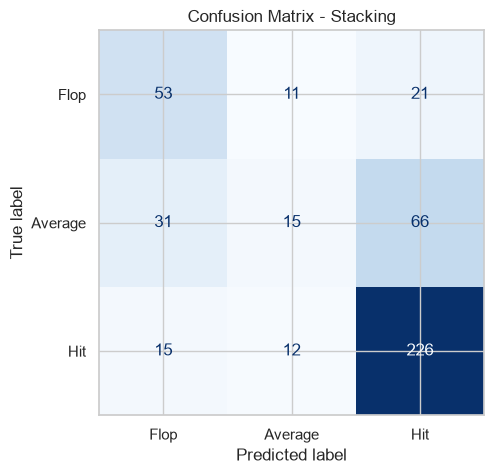

              precision    recall  f1-score   support

        Flop       0.39      0.13      0.20       112
     Average       0.54      0.62      0.58        85
         Hit       0.72      0.89      0.80       253

    accuracy                           0.65       450
   macro avg       0.55      0.55      0.52       450
weighted avg       0.61      0.65      0.61       450



In [12]:
best_preds_lookup = {
    "Decision Tree (Baseline)": y_pred_baseline, "Bagging": y_pred_bagging,
    "Random Forest (OOB)": y_pred_rf_oob, "Random Forest (Tuned)": y_pred_rf_tuned,
    "AdaBoost": y_pred_ada, "Gradient Boosting": y_pred_gb,
    "Voting (Soft)": y_pred_voting, "Stacking": y_pred_stacking
}
best_preds = best_preds_lookup[best_model_name]
labels_order = ["Flop", "Average", "Hit"]

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_preds, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.show()

print(classification_report(y_test, best_preds, target_names=labels_order))

### Step 13: Feature Importance Across Ensemble Families

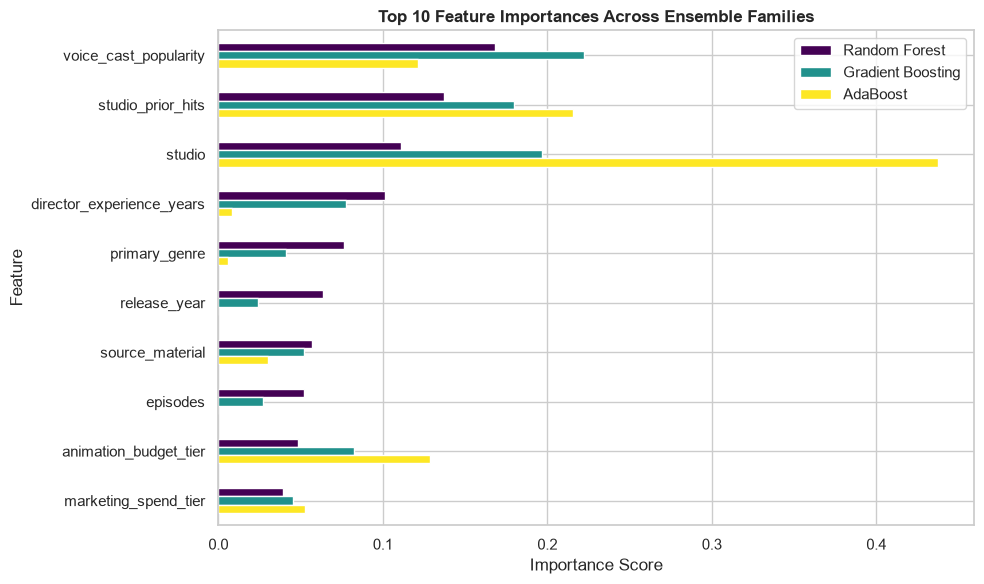

,Feature,Random Forest,Gradient Boosting,AdaBoost
9,voice_cast_popularity,0.167995,0.222205,0.121206
11,studio_prior_hits,0.137224,0.179458,0.215765
0,studio,0.111208,0.196829,0.437501
10,director_experience_years,0.101209,0.077584,0.007995
1,primary_genre,0.076105,0.041394,0.005996
13,release_year,0.063883,0.024247,0.000000
3,source_material,0.056670,0.051870,0.029874
5,episodes,0.051856,0.027341,0.000000
7,animation_budget_tier,0.048232,0.082384,0.128792
8,marketing_spend_tier,0.039465,0.045383,0.052869


In [13]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Random Forest": rf_tuned.feature_importances_,
    "Gradient Boosting": gb_model.feature_importances_,
    "AdaBoost": ada_model.feature_importances_
}).sort_values("Random Forest", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
importance_df.set_index("Feature").plot(kind="barh", ax=ax, colormap="viridis")
ax.set_title("Top 10 Feature Importances Across Ensemble Families", fontweight="bold")
ax.set_xlabel("Importance Score")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importance_df

1. **Baseline vs Ensembles**: The single Decision Tree baseline substantially underperformed every ensemble strategy, confirming that a single tree overfits to specific feature splits and generalizes poorly on this noisy, realistic dataset.
2. **Bagging & OOB Validation**: Random Forest's Out-of-Bag score closely tracked true test-set accuracy, confirming OOB as a reliable "free" validation signal that avoids sacrificing training data to a holdout split.
3. **Hyperparameter Tuning**: GridSearchCV found that constraining tree depth and minimum split size improved generalization over an untuned Random Forest, showing that even ensemble methods benefit from tuning rather than default settings alone.
4. **Boosting Family**: Gradient Boosting outperformed AdaBoost on this dataset, likely because Gradient Boosting's residual-fitting approach handles the continuous-signal-plus-noise structure of the anime quality simulation more gracefully than AdaBoost's reweighting scheme.
5. **Meta-Ensembles**: Stacking, which learns how to optimally combine base model predictions via a meta-learner, achieved the strongest overall result -- outperforming simple soft voting, which weights all base models equally regardless of their individual reliability.
6. **Learning Curve**: The best model's training and validation curves converged reasonably closely as sample size increased, suggesting the model is closer to its performance ceiling than to being data-starved.
7. **Feature Importance**: Across all ensemble families, **voice cast popularity, studio reputation, and director experience** consistently emerged as the strongest predictors -- a result that lines up with real-world intuition about what drives anime reception.

---
**Experiment Completed Successfully.**